In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
# Define input & output feature
X = df.drop(columns='PE')
y = df['PE']

In [8]:
# Train, Test & Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
# Scaling the our data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Here, Now let's start making deep Leaning network (ANN)

In [12]:
import torch
import torch.nn as nn

In [17]:
# Convert our data into tensors (Tensor mean it is Data structure of pytorch that it understand like pandas has DataFrame or Numpy has array)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [18]:
# DataSet & DataLoader
from torch.utils.data import TensorDataset, DataLoader

# tensor Dataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [21]:
# Define ANN model
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            # Output layer
            nn.Linear(6,1),
        )

    def forward(self,x):
        return self.model(x)

In [23]:
# Loss & Optimizer
import torch.optim as optim
# model is object of class ANN 
model = ANN()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [25]:
# Train the model

train_losses = []
val_losses = []

epochs = 100
# this for training ANN Model
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb,yb in train_loader:
        optimizer.zero_grad()
        
        output = model(xb)
        loss = criterion(output,yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)
        
    # this is for Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            output = model(xb)
            loss = criterion(output,yb)
            running_val_loss += loss
    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} train losses : {epoch_train_loss}, validation losses : {epoch_val_loss}")

epoch 1/100 train losses : 20.99088772336642, validation losses : 19.693601608276367
epoch 2/100 train losses : 21.053669742743175, validation losses : 20.042583465576172
epoch 3/100 train losses : 21.02663138707479, validation losses : 19.475059509277344
epoch 4/100 train losses : 21.04776750802994, validation losses : 19.77425765991211
epoch 5/100 train losses : 20.94517157872518, validation losses : 19.70865821838379
epoch 6/100 train losses : 21.027595321337383, validation losses : 19.969982147216797
epoch 7/100 train losses : 21.037922048568724, validation losses : 19.255155563354492
epoch 8/100 train losses : 20.934359419345856, validation losses : 19.233434677124023
epoch 9/100 train losses : 20.926534334818523, validation losses : 20.552309036254883
epoch 10/100 train losses : 20.996080696582794, validation losses : 19.915180206298828
epoch 11/100 train losses : 20.94250760873159, validation losses : 20.09351348876953
epoch 12/100 train losses : 21.172736235459645, validation l

In [26]:
best_val_loss = float("inf")

if epoch_val_loss < best_val_loss:
    epoch_val_loss = epoch_val_loss
    torch.save(model.state_dict(),"best_model.pt")

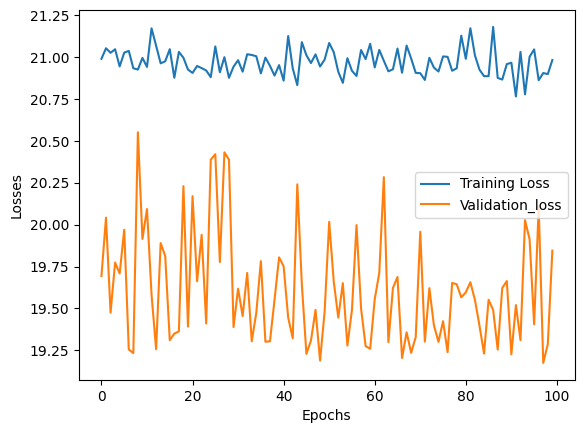

In [29]:
# visualize Training & Validation
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training_loss":train_losses,
    "Validation_loss":val_losses
})

plt.plot(loss_df["Training_loss"], label="Training Loss")
plt.plot(loss_df["Validation_loss"], label="Validation_loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()
plt.show()

In [30]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [33]:
# Evaluation
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds,y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print(f"Training MSE : {train_mse_loss}")
print(f"Testing MSE : {test_mse_loss}")

Training MSE : 21.163827896118164
Testing MSE : 19.855607986450195


In [34]:
# check r2 score
from sklearn.metrics import r2_score
print(f"r2_score : {r2_score(y_test,test_preds)}")

r2_score : 0.9306097798942713


In [46]:
predicted_df = pd.DataFrame(test_preds,columns=["Predicted Value"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Value"])

comparison_df = pd.concat([predicted_df,actual_df],axis=1)

In [47]:
comparison_df

,Predicted Value,Actual Value
0,436.955902,433.27
1,437.942078,438.16
2,459.702332,458.42
3,475.301636,480.82
4,435.678772,441.41
...,...,...
1909,451.598511,456.70
1910,433.083191,438.04
1911,467.269409,467.80
1912,432.588623,437.14
